# Shape analysis

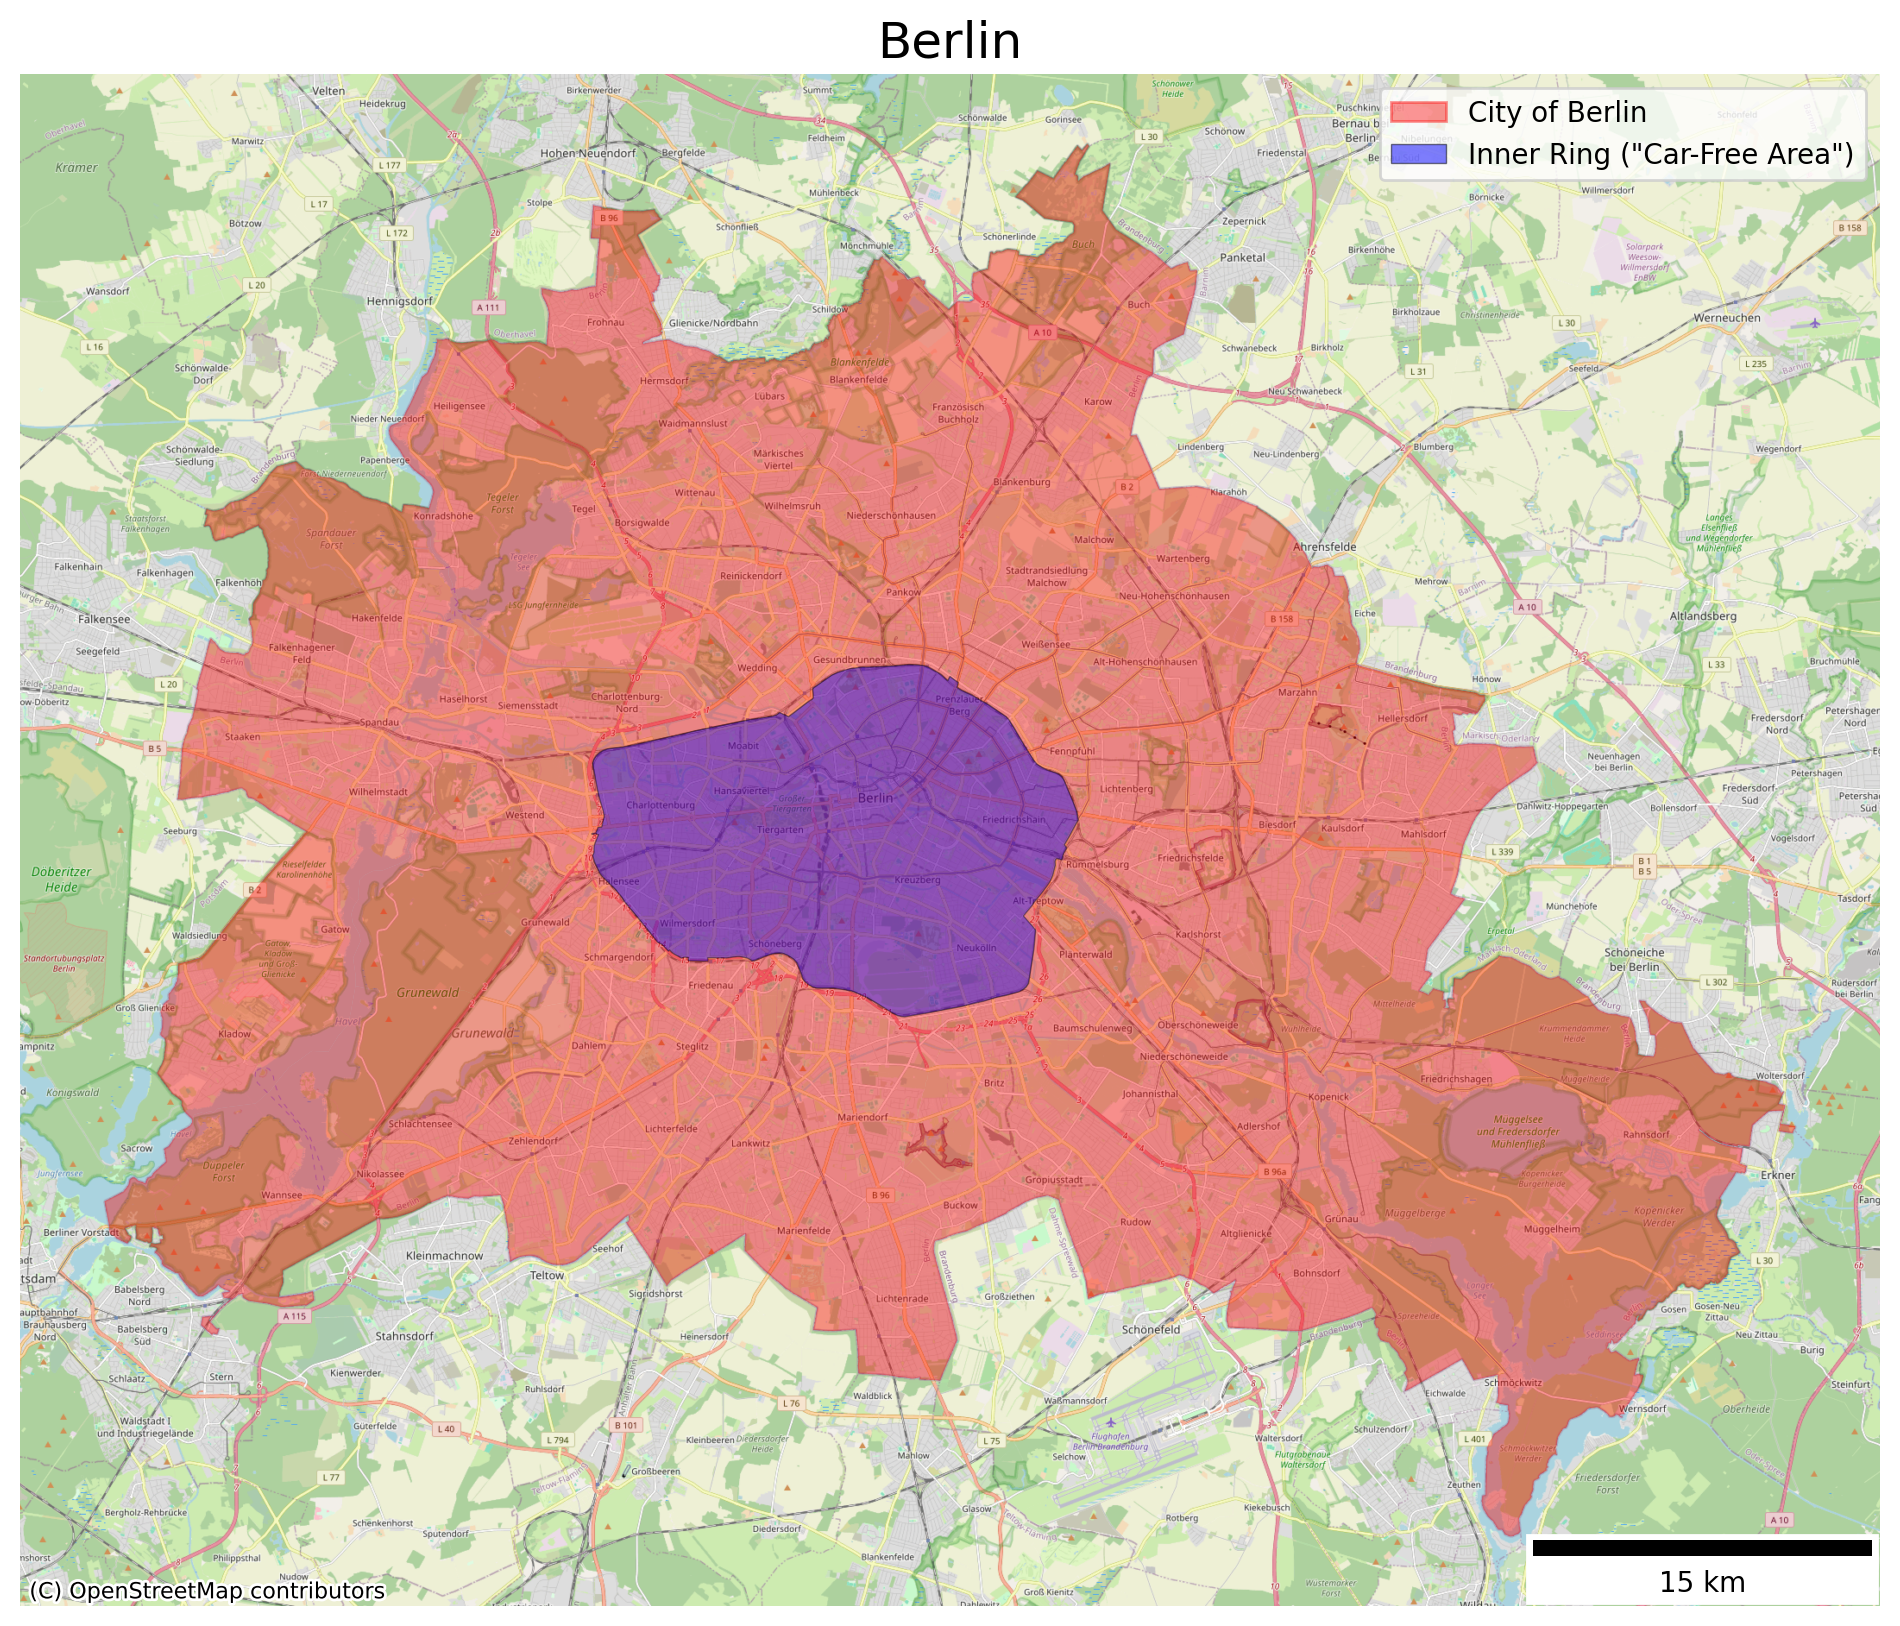

In [1]:
import contextily as ctx
import geopandas as gpd
import matplotlib.pyplot as plt
from geopandas import GeoDataFrame
from matplotlib.patches import Patch
from matplotlib_scalebar.scalebar import ScaleBar

%config InlineBackend.figure_format = 'retina'

gdf = gpd.read_file('../../../../input/v6.4/umweltzone/Umweltzone_Berlin.shp')
bezirke = gpd.read_file("/Users/paulh/git/matsim-berlin/input/v6.4/bezirksgrenzen.geojson")

gdf = gdf.to_crs(epsg=3857)
bezirke = bezirke.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 12))

# Plot layers (labels here won't be used by legend; we add proxies below)
bezirke.plot(
    ax=ax,
    facecolor="red",
    # edgecolor="black",
    # edgecolor="red",
    # linewidth=1.0,
    alpha=0.4,
)

gdf.plot(
    ax=ax,
    facecolor="blue",
    edgecolor="black",
    linewidth=0.5,
    alpha=0.4,
)

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, zoom=12)

scalebar = ScaleBar(dx=1, units="m", location="lower right", scale_loc="bottom")
ax.add_artist(scalebar)

# --- Manual legend with proxy artists ---
legend_handles = [
    Patch(facecolor="red", edgecolor="red", alpha=0.4, linewidth=1.0, label="City of Berlin"),
    Patch(facecolor="blue", edgecolor="black", linewidth=0.5, alpha=0.5, label='Inner Ring ("Car-Free Area")'),
]
ax.legend(handles=legend_handles, loc="upper right", frameon=True)

ax.set_axis_off()
ax.set_title('Berlin', fontsize=18)
plt.savefig("berlin.png", dpi=300)
plt.show()

# Link Stat Analysis

In [80]:
import pandas as pd

pct = 0.01


def read_links(input_path) -> GeoDataFrame:
    df_links = pd.read_csv(
        input_path,
        sep=";",
        compression="zstd",
        dtype={"link": "string"},
        low_memory=False,
    )

    links = gpd.GeoDataFrame(
        df_links[~df_links["link"].str.contains("pt_")],
        geometry=gpd.GeoSeries.from_wkt(df_links["geometry"], crs="EPSG:25832"),
    )

    pcu_factors = {
        "vol_car": 1,
        "vol_freight": 3.5,
        "vol_truck": 3.5,
        "vol_commercial_goods_car": 1.0
    }

    links["vol_scaled"] = (
            sum(links.get(col, 0) * factor for col, factor in pcu_factors.items()) / pct
    )
    return links


def plot_link_volumes(links, max_vol, zone):
    links_3857 = links.to_crs(epsg=3857)
    links_3857["geometry"] = links_3857.geometry.simplify(2)

    bezirke_union = bezirke.geometry.union_all()
    links_3857 = links_3857[links_3857.intersects(bezirke_union)]

    minx, miny, maxx, maxy = bezirke.total_bounds

    x_diff = maxx - minx
    y_diff = maxy - miny
    buffer_factor = -0.3
    minx -= x_diff * buffer_factor * 0.8
    maxx += x_diff * buffer_factor * 1.2
    miny -= y_diff * buffer_factor
    maxy += y_diff * buffer_factor

    # Thickness ~ capacity (clipped to robust quantiles for readability)
    cap = links_3857["capacity"].astype(float)
    cap_q_low, cap_q_high = cap.quantile([0.02, 0.98])
    cap_clip = cap.clip(lower=cap_q_low, upper=cap_q_high)

    # normalize capacity value to 0.0 - 1.0
    cap_norm = (cap_clip - cap_q_low) / (cap_q_high - cap_q_low) if cap_q_high > cap_q_low else cap_clip * 0 + 0.5
    links_3857["_lw"] = 0.2 + cap_norm * 3.0  # linewidth range ~ [0.2, 3.2]

    vmax = float(max_vol.max()) if hasattr(max_vol, "max") else float(max_vol)

    fig, ax = plt.subplots(figsize=(12, 12))
    # links_3857.plot(
    #     ax=ax,
    #     column="vol_scaled",
    #     cmap="bwr",
    #     linewidth=links_3857["_lw"],
    #     alpha=0.8,
    #     legend=True,
    #     legend_kwds={"label": "Traffic volume in PCU", "shrink": 0.6},
    #     vmin=links["vol_scaled"].min(),
    #     vmax=vmax,
    # )

    from matplotlib.colors import TwoSlopeNorm

    norm = TwoSlopeNorm(
        vmin=links_3857["vol_scaled"].min(),
        vcenter=0,
        vmax=vmax,
    )

    links_3857.plot(
        ax=ax,
        column="vol_scaled",
        cmap="bwr",
        norm=norm,
        linewidth=links_3857["_lw"],
        alpha=0.8,
        legend=True,
        legend_kwds={"label": "Traffic volume in PCU", "shrink": 0.6},
        # vmin=0,
        # vmax=vmax,
    )

    zone.plot(
        ax=ax,
        facecolor="green",
        edgecolor="black",
        linewidth=0.5,
        alpha=0.2,
    )

    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=12)
    ax.set_axis_off()
    ax.set_title("Links (capacity -> thickness, vol_scaled -> color)", fontsize=16)

    ax.set_xlim([minx, maxx])
    ax.set_ylim([miny, maxy])

    plt.show()


In [53]:
base_path = "/Users/paulh/runs-svn/matsim-berlin/autofrei/1pct-v6.4/berlin-autofrei-v6.4-baseCaseCtdExtended/berlin-v6.4.output_links.csv.zst"
base_links = read_links(base_path)

policy_path = "/Users/paulh/runs-svn/matsim-berlin/autofrei/1pct-v6.4/berlin-autofrei-v6.4-policy/berlin-v6.4.output_links.csv.zst"
policy_links = read_links(policy_path)

max_vol = max(base_links["vol_scaled"].max(), policy_links["vol_scaled"].max())

ValueError: vmin, vcenter, and vmax must be in ascending order

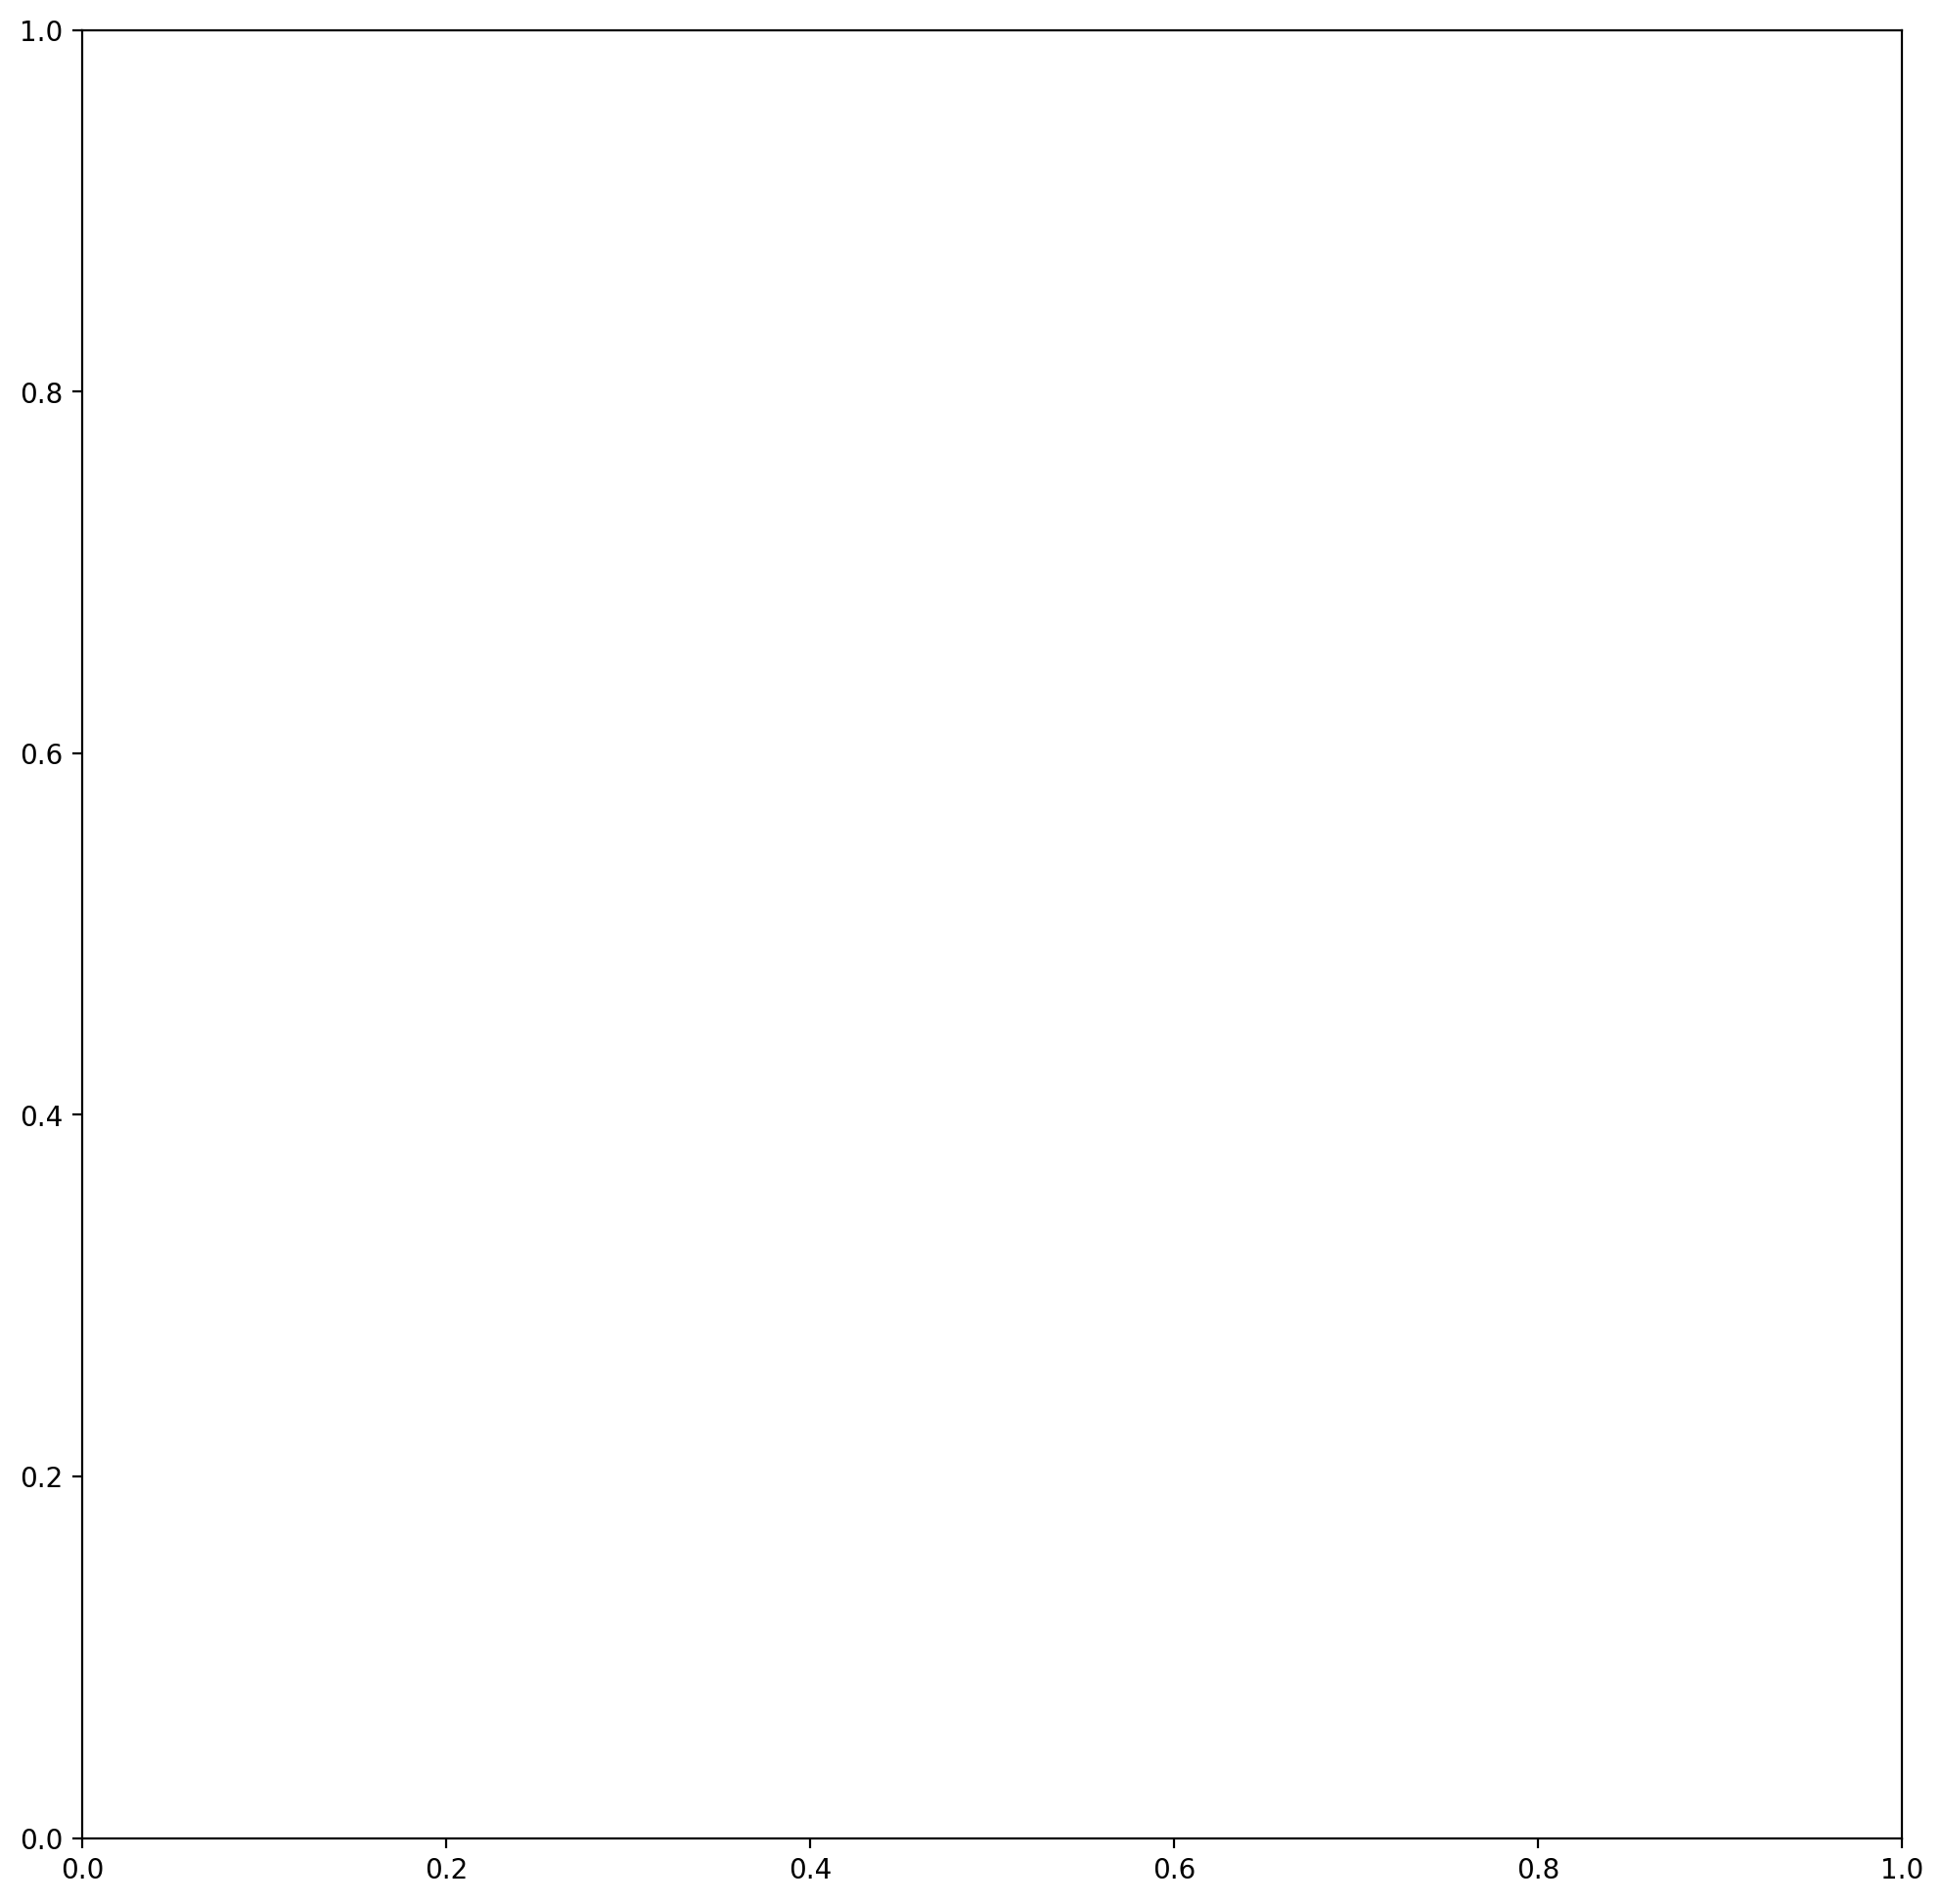

In [56]:
plot_link_volumes(base_links, max_vol)

In [ ]:
plot_link_volumes(policy_links, max_vol)

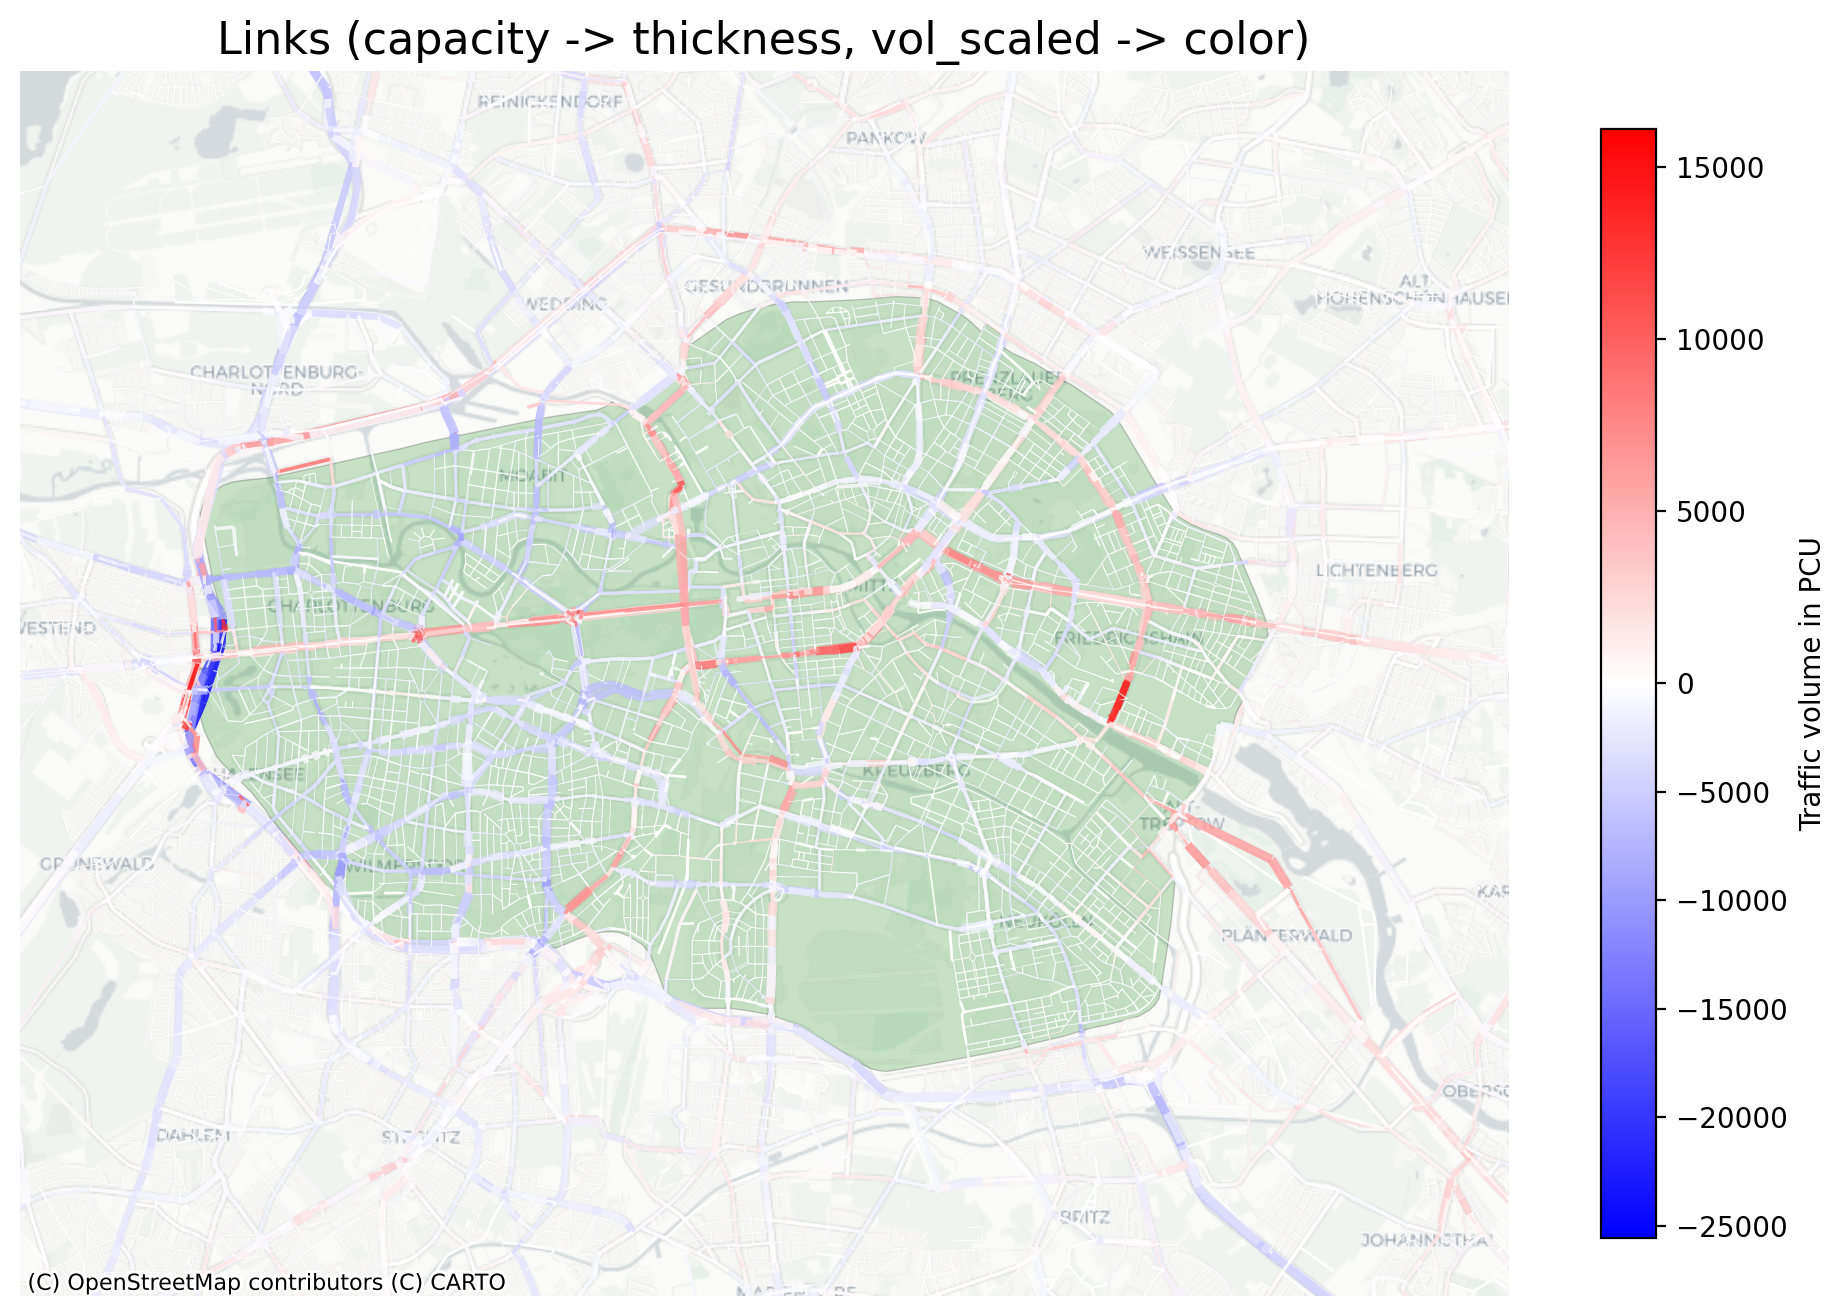

In [81]:
diff_links = (
    base_links[["link", "geometry", "vol_scaled", "capacity"]]
    .rename(columns={"vol_scaled": "vol_scaled_base"})
    .merge(
        policy_links[["link", "vol_scaled"]].rename(columns={"vol_scaled": "vol_scaled_policy"}),
        on="link",
        how="inner",
    )
)

diff_links["vol_scaled"] = diff_links["vol_scaled_policy"] - diff_links["vol_scaled_base"]
diff_links = gpd.GeoDataFrame(diff_links, geometry="geometry", crs=base_links.crs)

plot_link_volumes(diff_links, diff_links["vol_scaled"].max(), gdf)